In [1]:
import sys
import os
import torch
import matplotlib.pyplot as plt
import numpy as np

sys.path.append('..')

from src.model import CNN

In [4]:
model_path = '../results/models/cnn_float32.pth'

if not os.path.exists(model_path):
   print(f"Warnung: Modell existiert nicht unter {model_path}")
else:
   model = CNN()
   model.load_state_dict(torch.load(model_path))
   print("Modell geladen.")


Modell geladen.


In [5]:
weights_floats = model.conv1.weight.data.clone()
print(f"Shape der Gewichte: {weights_floats.shape}")
print(f"Min Wert: {weights_floats.min():.4f}, Max Wert: {weights_floats.max():.4f}")

flat_float = weights_floats.view(-1).numpy()

Shape der Gewichte: torch.Size([32, 1, 3, 3])
Min Wert: -0.5508, Max Wert: 0.4185


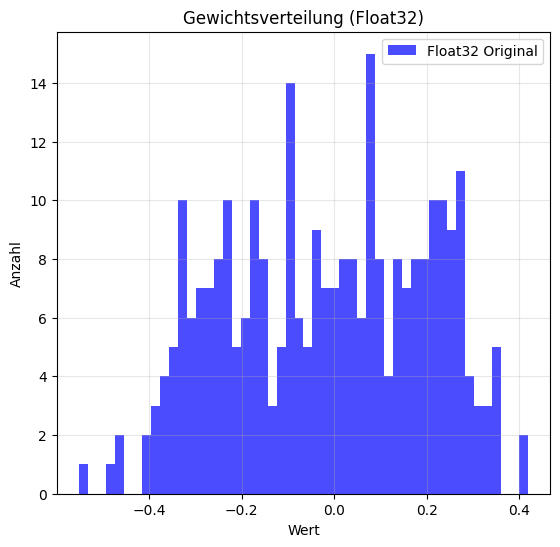

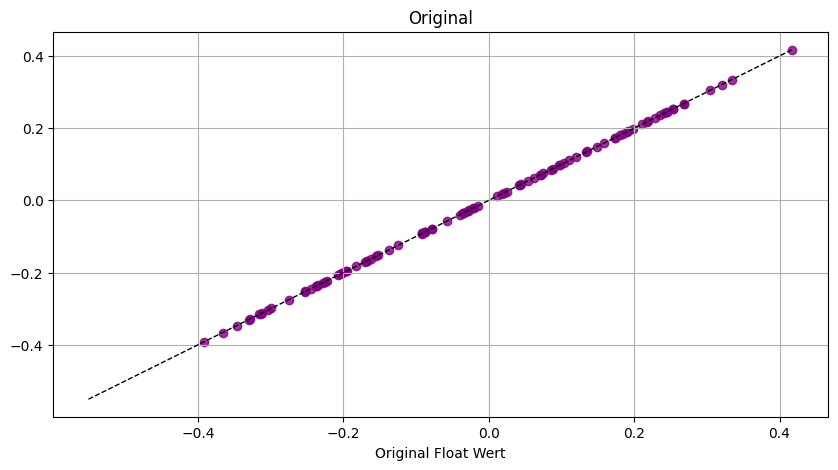

In [9]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.hist(flat_float, bins=50, color='blue', alpha=0.7, label="Float32 Original")
plt.title("Gewichtsverteilung (Float32)")
plt.xlabel("Wert")
plt.ylabel("Anzahl")
plt.legend()
plt.grid(True,alpha=0.3)

plt.show()

plt.figure(figsize=(10,5))
plt.scatter(flat_float[:100], flat_float[:100], alpha=0.8, c='purple')
plt.plot([flat_float.min(), flat_float.max()], [flat_float.min(), flat_float.max()], 'k--', lw=1)
plt.title("Original")
plt.xlabel("Original Float Wert")
plt.ylabel("")
plt.grid(True)
plt.show()